[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch06-concepts_workbook.ipynb)

# Three scores and one unit of weight

A decoder writing `black` scores the French words `le`, `chat` and `noir`
and shares one unit of weight among them. Does `le`, with the lowest score,
get any weight? What does the decoder read from the three words once the
weights are set?

In [1]:
#@title Setup: run this cell first
import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# The book's three French words as two-number encoder states.
STATES = {"le": [1, 0], "chat": [1, 1], "noir": [0, 2]}
WORDS = list(STATES)
plt.rcParams.update({"xtick.labelsize": 8, "ytick.labelsize": 8})


class Refused(Exception):  # a setting a cell refuses: Colab prints the one sentence, without the stack
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def fmt(v):  # a vector as (0.335, 1.575)
    return "(" + ", ".join(f"{x + 0.0:.3f}" for x in v) + ")"


def numbers(name, x, n, lo=-20, hi=20):  # a setting typed in a cell: a list of n numbers from lo to hi
    if not (isinstance(x, (list, tuple)) and len(x) == n and all(type(v) in (int, float) and lo <= v <= hi for v in x)):
        raise Refused(f"{name} is {x!r}: {name} takes a list of {n} numbers from {lo} to {hi}.")
    return np.array(x, dtype=float)


def softmax(scores):  # e to each score, divided by the sum
    z = np.exp(scores - np.max(scores))
    return z / z.sum()


def bars(title, labels, values, xlabel, focus):  # one chart of labelled bars, the focus in red
    fig, ax = plt.subplots(figsize=(6, 0.45 * len(values) + 1.2), layout="constrained")
    b = ax.barh(range(len(values)), values, tick_label=labels, color=["C3" if x == focus else "C0" for x in labels])
    ax.bar_label(b, fmt="%.3f", padding=2, fontsize=8)
    lo, hi = min(0, *values), max(0, *values)
    ax.set(title=title, xlabel=xlabel, xlim=(lo - 0.3 * (hi - lo) if lo < 0 else 0, hi + 0.3 * (hi - lo)), ylim=(len(values) - 0.5, -0.5))
    plt.show()


# Step 1: the softmax weights of three scores.
def weights(scores):
    s = numbers("SCORES", scores, 3)
    print("e to each score: " + ", ".join(f"{math.exp(v):.3f}" for v in s) + f"; sum {sum(math.exp(v) for v in s):.3f}")
    bars("softmax weights of the three words", WORDS, list(softmax(s)), "weight", "le")


# Step 2: the context vector, the states added in proportion to their weights.
def context(weights_typed):
    w = numbers("WEIGHTS", weights_typed, 3, 0, 1)
    if abs(w.sum() - 1) > 0.01:
        raise Refused(f"WEIGHTS is {weights_typed!r}: WEIGHTS takes three numbers from 0 to 1 that add up to 1.")
    c = sum(wj * np.array(STATES[k]) for wj, k in zip(w, WORDS))
    print(" + ".join(f"{wj:.3f} × {fmt(STATES[k])}" for wj, k in zip(w, WORDS)), "=", fmt(c))
    fig, ax = plt.subplots(figsize=(4, 3.6), layout="constrained")
    for k in WORDS:
        ax.annotate("", STATES[k], (0, 0), arrowprops=dict(arrowstyle="->", color="0.5"))
        ax.text(STATES[k][0] + 0.04, STATES[k][1], k, fontsize=9)
    ax.annotate("", tuple(c), (0, 0), arrowprops=dict(arrowstyle="->", color="C3", lw=2))
    ax.text(c[0] + 0.04, c[1] - 0.12, "context vector", color="C3", fontsize=9)
    ax.set(xlim=(-0.1, 1.5), ylim=(-0.1, 2.2), aspect="equal", title="the three states and the context vector")
    plt.show()


# Step 3: self-attention, each word scoring every word by the dot product, itself included.
def self_attention(x):
    if not isinstance(x, dict) or sorted(x) != sorted(WORDS):
        raise Refused(f"X is {x!r}: X takes a vector for each of le, chat and noir, such as {STATES}.")
    X = np.array([numbers(k, x[k], 2, -5, 5) for k in WORDS])
    W = np.array([softmax(row) for row in X @ X.T])
    for k, row, z in zip(WORDS, W, W @ X):
        print(f"{k:>5}: weights {fmt(row)}, output {fmt(z)}")
    fig, ax = plt.subplots(figsize=(4, 3.2), layout="constrained")
    ax.imshow(W, cmap="Blues", vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{W[i, j]:.3f}", ha="center", va="center", color="white" if W[i, j] > 0.6 else "black", fontsize=9)
    ax.set(xticks=range(3), xticklabels=WORDS, yticks=range(3), yticklabels=WORDS, xlabel="weighted word", ylabel="query word",
           title="self-attention weights")
    plt.show()


# Appendix: Bahdanau's additive score from the sum before tanh and the vector v.
def additive(total, v):
    t, v = np.tanh(numbers("SUM", total, 4, -5, 5)), numbers("V", v, 4, -5, 5)
    print(f"tanh {fmt(t)}; products {fmt(t * v)}; score {float(t @ v):.3f}")
    bars("the four products and the score", ["entry 1", "entry 2", "entry 3", "entry 4", "score"], list(t * v) + [float(t @ v)], "value", "score")


display(Markdown("The encoder states: " + ", ".join(f"`{k}` {fmt(v)}" for k, v in STATES.items()) + "."))

The encoder states: `le` (1.000, 0.000), `chat` (1.000, 1.000), `noir` (0.000, 2.000).

## 1. Softmax weights

The softmax raises e to each score and divides by the sum, so every weight is
positive and the three add up to 1. The decoder writing `black` scores `le`,
`chat` and `noir` 0, 1 and 2. Run the cell: does `le` get any weight? Then
set `SCORES` to `[0, 2, 2]`, and to `[10, 11, 12]`.

e to each score: 1.000, 2.718, 7.389; sum 11.107


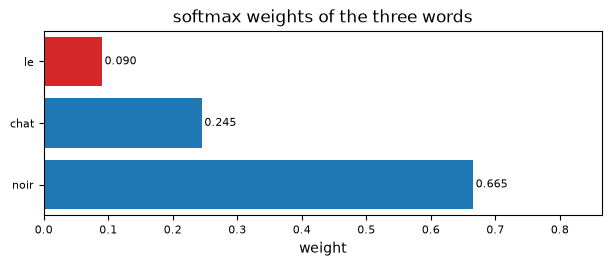

In [2]:
SCORES = [0, 1, 2]  # le, chat, noir
weights(SCORES)

### Solution

In [3]:
w, w2, w3 = softmax(np.array([0, 1, 2])), softmax(np.array([0, 2, 2])), softmax(np.array([10, 11, 12]))
display(Markdown(f"Scores 0, 1 and 2 give the weights {fmt(w)}: `le` keeps {w[0]:.3f}, and `noir` gets e = {w[2] / w[1]:.3f} times "
                 f"the weight of `chat`, one unit of score higher. Scores 0, 2 and 2 give {fmt(w2)}. Scores 10, 11 and 12 give "
                 f"{fmt(w3)}, the weights of 0, 1 and 2: adding one number to every score changes no weight."))

Scores 0, 1 and 2 give the weights (0.090, 0.245, 0.665): `le` keeps 0.090, and `noir` gets e = 2.718 times the weight of `chat`, one unit of score higher. Scores 0, 2 and 2 give (0.063, 0.468, 0.468). Scores 10, 11 and 12 give (0.090, 0.245, 0.665), the weights of 0, 1 and 2: adding one number to every score changes no weight.

## 2. The context vector

The decoder adds the three states, each multiplied by its weight, into one
context vector of two numbers. Run the cell with the weights of `black`:
where does the context vector point? Then set `WEIGHTS` to the weights of
`cat`, `[0.212, 0.576, 0.212]`, and to equal weights, `[1/3, 1/3, 1/3]`.

0.090 × (1.000, 0.000) + 0.245 × (1.000, 1.000) + 0.665 × (0.000, 2.000) = (0.335, 1.575)


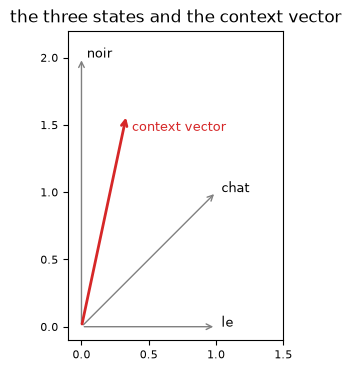

In [4]:
WEIGHTS = [0.090, 0.245, 0.665]  # le, chat, noir
context(WEIGHTS)

### Solution

In [5]:
ctx = {k: sum(wj * np.array(STATES[x]) for wj, x in zip(v, WORDS))
       for k, v in (("black", [0.090, 0.245, 0.665]), ("cat", [0.212, 0.576, 0.212]), ("equal", [1 / 3] * 3))}
display(Markdown(f"The weights of `black` give {fmt(ctx['black'])}, close to `noir`, which holds 0.665 of the weight; those of `cat` "
                 f"give {fmt(ctx['cat'])}. Equal weights give the mean of the three states, {fmt(ctx['equal'])}, the same "
                 "vector for every word the decoder writes."))

The weights of `black` give (0.335, 1.575), close to `noir`, which holds 0.665 of the weight; those of `cat` give (0.788, 1.000). Equal weights give the mean of the three states, (0.667, 1.000), the same vector for every word the decoder writes.

## 3. A sentence attending to itself

In self-attention each word is query, key and value at once: every word
scores every word of `le chat noir`, itself included, by the dot product, and
its output adds the three vectors by its weights. Run the cell: how much of
its own weight does `noir` keep? Then set `noir` to `[0, 4]` and run it
again.

   le: weights (0.422, 0.422, 0.155), output (0.845, 0.733)
 chat: weights (0.155, 0.422, 0.422), output (0.578, 1.267)
 noir: weights (0.016, 0.117, 0.867), output (0.133, 1.851)


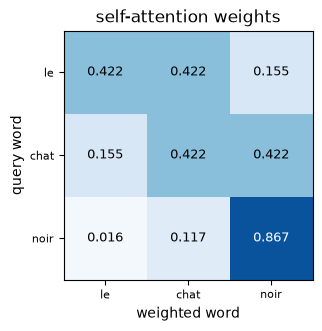

In [6]:
X = {"le": [1, 0], "chat": [1, 1], "noir": [0, 2]}
self_attention(X)

### Solution

In [7]:
X0 = np.array([[1, 0], [1, 1], [0, 2]])
W0 = np.array([softmax(row) for row in X0 @ X0.T])
X4 = np.array([[1, 0], [1, 1], [0, 4]])
display(Markdown(f"`noir` scores 4 with itself and keeps {W0[2, 2]:.3f} of its weight; `chat` mixes the three into "
                 f"{fmt(W0[1] @ X0)}. At `[0, 4]`, `noir` scores 16 with itself and keeps {softmax(X4[2] @ X4.T)[2]:.3f}: "
                 "a longer vector scores higher with itself, and the dot product grows with length."))

`noir` scores 4 with itself and keeps 0.867 of its weight; `chat` mixes the three into (0.578, 1.267). At `[0, 4]`, `noir` scores 16 with itself and keeps 1.000: a longer vector scores higher with itself, and the dot product grows with length.

## Appendix. Bahdanau's additive score

The formulas behind the three steps:

weight of word j = e to its score, divided by the sum of e to every score

context vector = the sum over the words of weight × state

self-attention output of a word = the sum over the words of its weight × vector, with every score a dot product of two vectors of the sentence

Bahdanau's additive score passes query and key through one tanh layer:
score = v · tanh(W_s × decoder state + W_h × encoder state). In the book's
example the sum inside tanh is `[0.7, 0.1, 0.2, 0.8]` and `v` is
`[0.3, 0.5, -0.2, 0.4]`; the chart shows the four products and the score.

tanh (0.604, 0.100, 0.197, 0.664); products (0.181, 0.050, -0.039, 0.266); score 0.457


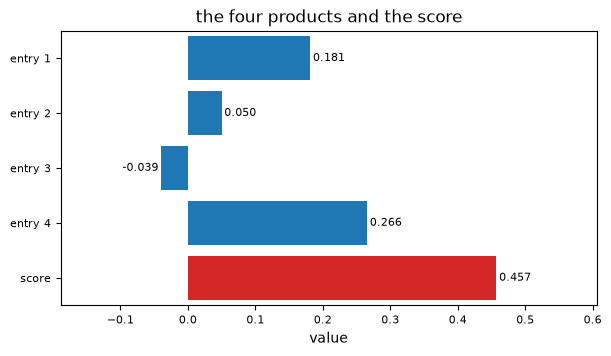

In [8]:
additive([0.7, 0.1, 0.2, 0.8], [0.3, 0.5, -0.2, 0.4])

**Exercise.** For the second source word the sum inside tanh is
`[0.1, 0.4, 0.8, 0.1]`. Set `SUM` to it and rerun the cell. Which source word
scores higher?

tanh (0.604, 0.100, 0.197, 0.664); products (0.181, 0.050, -0.039, 0.266); score 0.457


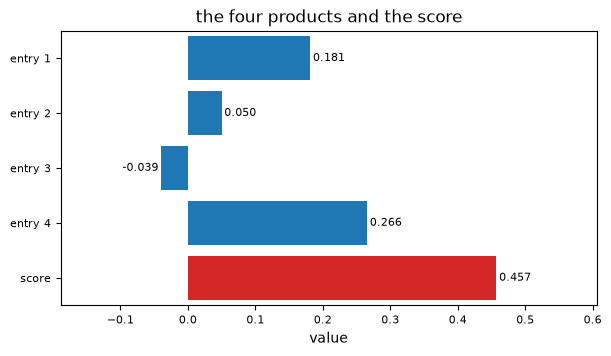

In [9]:
SUM, V = [0.7, 0.1, 0.2, 0.8], [0.3, 0.5, -0.2, 0.4]
additive(SUM, V)

### Solution

In [10]:
v = np.array([0.3, 0.5, -0.2, 0.4])
e1, e2 = np.tanh([0.7, 0.1, 0.2, 0.8]) @ v, np.tanh([0.1, 0.4, 0.8, 0.1]) @ v
display(Markdown(f"The first source word scores {e1:.3f} and the second {e2:.3f}, so the first scores higher. The lecture "
                 f"rounds each product to three places before adding, which gives {sum(np.round(np.tanh([0.7, 0.1, 0.2, 0.8]) * v, 3)):.3f} "
                 "for the first."))

The first source word scores 0.457 and the second 0.127, so the first scores higher. The lecture rounds each product to three places before adding, which gives 0.458 for the first.